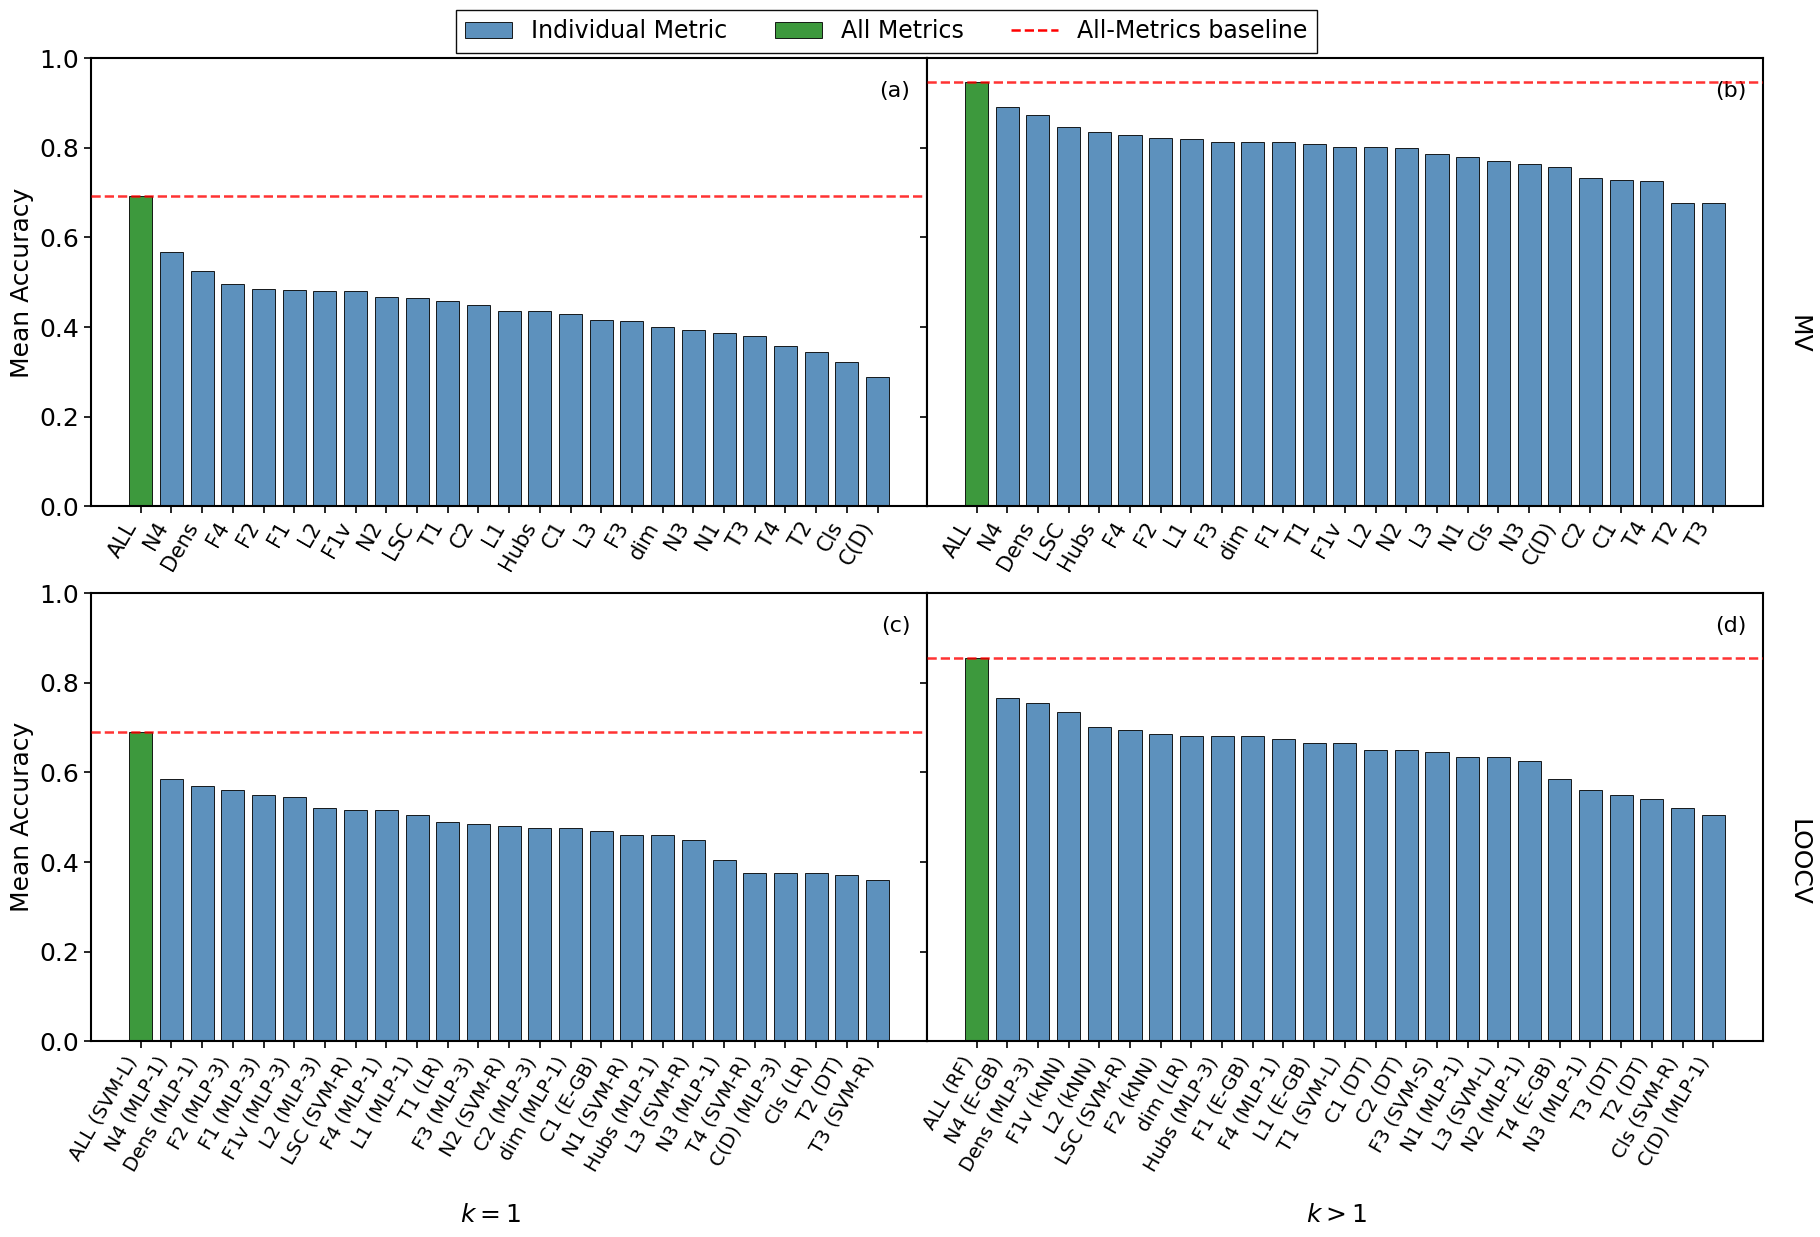

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

df_1a_mv = pd.read_csv("mv_taska_results.csv")
df_1b_mv = pd.read_csv("mv_taskb_results.csv")

loocv_1a_path = "loocv_taska_results.csv"
loocv_1b_path = "loocv_taskb_results.csv"

if os.path.exists(loocv_1a_path) and os.path.exists(loocv_1b_path):
    df_1a_loocv = pd.read_csv(loocv_1a_path)
    df_1b_loocv = pd.read_csv(loocv_1b_path)
else:
    df_1a_loocv = df_1a_mv.copy()
    df_1b_loocv = df_1b_mv.copy()

plt.rcParams.update(plt.rcParamsDefault)  
plt.rcParams.update({
    'font.size': 17,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
})

COLOR_SINGLE = '#4682B4'
COLOR_ALL    = '#228B22'

CLF_SHORT = {
    'DT': 'DT', 'RF': 'RF',
    'Ensemble-GB': 'E-GB', 'Ensemble-AB': 'E-AB', 'Ensemble-Bg': 'E-Bg',
    'SVM-Linear': 'SVM-L', 'SVM-RBF': 'SVM-R', 'SVM-Sigmoid': 'SVM-S',
    'MLP-500': 'MLP-1', 'MLP-100-100-100': 'MLP-3',
    'kNN': 'kNN', 'NearestCentroid': 'NC',
    'NaiveBayes': 'NB', 'LogisticRegression': 'LR',
}

METRIC_SHORT = {
    'ALL_METRICS': 'ALL',
    'kolmogorov': 'C(D)',
    'intrinsic': 'dim',
    'density': 'Dens',
    'clsCoef': 'Cls',
    'hubs': 'Hubs',
    'f1v': 'F1v',
    'lsc': 'LSC',
}

def make_tick_label(row, has_classifier):
    metric = row['Metric']
    short = METRIC_SHORT.get(metric, metric.upper())
    if has_classifier and 'Classifier' in row.index:
        clf = CLF_SHORT.get(row['Classifier'], row['Classifier'])
        return f"{short} ({clf})"
    return short


def plot_panel(ax, df_plot, panel_label, ylim,
               show_xticks=True, show_yticks=True):
    df_plot = df_plot.sort_values('Mean_Acc', ascending=False).reset_index(drop=True)
    all_row = df_plot[df_plot['Metric'] == 'ALL_METRICS'].iloc[0]
    has_clf = 'Classifier' in df_plot.columns

    x = np.arange(len(df_plot))
    colors = [COLOR_ALL if m == 'ALL_METRICS' else COLOR_SINGLE
              for m in df_plot['Metric']]

    ax.bar(x, df_plot['Mean_Acc'].values,
           color=colors, alpha=0.88,
           edgecolor='black', linewidth=0.7, width=0.75)

    if show_xticks:
        labels = [make_tick_label(row, has_clf) for _, row in df_plot.iterrows()]
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=60, ha='right',
                           fontsize=14 if has_clf else 15)
    else:
        ax.set_xticks(x)
        ax.set_xticklabels([])

    if show_yticks:
        ax.set_ylabel('Mean Accuracy')
    else:
        ax.yaxis.set_tick_params(which='both', left=True, labelleft=False)
        ax.set_yticklabels([])

    ax.text(0.98, 0.95, f'({panel_label})', transform=ax.transAxes,
            fontsize=16, va='top', ha='right')

    ax.axhline(y=all_row['Mean_Acc'], color='red', linestyle='--',
               linewidth=1.8, alpha=0.8, zorder=5)

    ax.set_ylim(ylim)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)


ylim_row1 = (0, 1.0)   # MV row
ylim_row2 = (0, 1.0)   # LOOCV row

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# MV row
plot_panel(axes[0, 0], df_1a_mv,    'a', ylim_row1, show_xticks=True, show_yticks=True)
plot_panel(axes[0, 1], df_1b_mv,    'b', ylim_row1, show_xticks=True, show_yticks=False)
# LOOCV row
plot_panel(axes[1, 0], df_1a_loocv, 'c', ylim_row2, show_xticks=True, show_yticks=True)
plot_panel(axes[1, 1], df_1b_loocv, 'd', ylim_row2, show_xticks=True, show_yticks=False)

plt.tight_layout(pad=1.0, h_pad=0.5, w_pad=0.0)
fig.subplots_adjust(top=0.95, wspace=0.0)
# ── Row labels on the right ─────────────────────────────────
fig.text(1.00, 0.72, 'MV', fontsize=18,
         ha='left', va='center', rotation=-90)
fig.text(1.00, 0.28, 'LOOCV', fontsize=18,
         ha='left', va='center', rotation=-90)

# ── Column labels at bottom ──────────────────────────────────
fig.text(0.28, -0.02, r'$k = 1$', fontsize=18, ha='center')
fig.text(0.75, -0.02, r'$k > 1$', fontsize=18, ha='center')

# ── Single shared legend at top ──────────────────────────────
patch_single = mpatches.Patch(facecolor=COLOR_SINGLE, edgecolor='black',
                              linewidth=0.7, alpha=0.88, label='Individual Metric')
patch_all = mpatches.Patch(facecolor=COLOR_ALL, edgecolor='black',
                           linewidth=0.7, alpha=0.88, label='All Metrics')
line_ref = plt.Line2D([], [], color='red', linestyle='--', linewidth=1.8,
                      label='All-Metrics baseline')

fig.legend(handles=[patch_single, patch_all, line_ref],
           loc='upper center', ncol=3,
           framealpha=0.95, edgecolor='black', fancybox=False,
           fontsize=17, bbox_to_anchor=(0.5, 1.00))

plt.savefig('revised_figure_2x2_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('revised_figure_2x2_metrics_comparison.pdf', dpi=300, bbox_inches='tight')
plt.savefig('revised_figure_2x2_metrics_comparison.svg', bbox_inches='tight')
plt.show()